In [73]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold,RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import HuberRegressor
import xgboost as xgb
from xgboost import XGBRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt
from sklearn.ensemble import VotingRegressor
import pickle


In [74]:
df_all=pd.read_csv('umap_all_data.csv')
df_umap=pd.read_csv('umap_target_data.csv')

In [75]:
#отделяем признаки от целевой переменной и делаем ее логарифмирование
targets = ['IC50, mM', 'CC50, mM', 'SI']
all_features = [col for col in df_all.columns if col not in targets]
X_all = df_all[all_features].copy()
all_features2 = [col for col in df_umap.columns if col not in targets]
X_umap = df_umap[all_features2].copy()
y_a = df_all['SI']
y_u = df_umap['SI']

In [76]:
#делим выборку на обучающую и валидационную
X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(X_all, y_a, test_size=0.2, random_state=42)
X_u_train, X_u_test, y_u_train, y_u_test = train_test_split(X_umap, y_u, test_size=0.2, random_state=42)
y_split_train_count = len(y_a_train)
y_split_test_count = len(y_a_test)
print(f'Размер обучающей выборки: {y_split_train_count}. Размер валидационной выборки {y_split_test_count}')

Размер обучающей выборки: 798. Размер валидационной выборки 200


In [77]:
scaler_robust = RobustScaler()
X_a_train_r = pd.DataFrame(scaler_robust.fit_transform(X_a_train), columns=X_a_train.columns, index=X_a_train.index)
X_a_test_r = pd.DataFrame(scaler_robust.transform(X_a_test), columns=X_a_test.columns, index=X_a_test.index)

In [78]:
#т.к. целевая переменная имеет скошенное распределние (медиана сильно отличается от среднего), делаем логарифмирование
y_train_log = np.log1p(y_a_train)
y_test_log = np.log1p(y_a_test)

In [79]:
y_u_train_log = np.log1p(y_u_train)
y_u_test_log = np.log1p(y_u_test)

In [80]:
#выбираем нелинейные модели для обучения
#определяем cv для кроссвалидации
models = {'Ridge':{'model': Ridge(random_state=42),
        'params': {'alpha': [0.01, 0.1, 1, 10, 50, 100]}},
          'Lasso': {'model': Lasso(random_state=42, max_iter=10000),
        'params': {'alpha': [0.001, 0.01, 0.1, 1, 10]}},
          'Random Forest': {'model': RandomForestRegressor(random_state=42, n_jobs=-1),
        'params': {'n_estimators': [200, 230, 300],
                   'max_depth': [10, 15,18],
                   'min_samples_split': [3, 4, 5],
                   'min_samples_leaf': [2, 3, 4]}},
          'Gradient Boosting': {'model': GradientBoostingRegressor(random_state=42),
        'params': {'n_estimators': [220, 250, 300],
                   'learning_rate': [0.02, 0.04, 0.06],
                   'max_depth': [3, 4, 5],
                   'subsample': [0.6, 0.8]}},
          'XGBoost': {'model': XGBRegressor(random_state=42, verbosity=0),
        'params': {'n_estimators': [220, 250, 300],
            'max_depth': [3, 4, 5],
            'learning_rate': [0.01, 0.03, 0.05]}},
          'LightGBM': {'model': LGBMRegressor(random_state=42, verbose=-1),
        'params': {'n_estimators': [100, 120, 140],
            'num_leaves': [7, 9, 11],
            'learning_rate': [0.05, 0.1]}},
          'SVM': {'model': SVR(),
        'params': {'C': [10, 20, 25],
                   'gamma': ['auto', 0.1],
                   'epsilon': [0.3, 0.5]}},
          'KNN': {'model': KNeighborsRegressor(),
        'params': {'n_neighbors': [12, 15, 18, 25],
                    'weights': ['uniform', 'distance'],
                   'metric': ['euclidean', 'manhattan']}}}


In [81]:
#обучаем модели и сохраняем лучшие результаты
results = []
best_models = {}
print('Модели на всех признаках')
for name, config in models.items():
  grid = GridSearchCV(config['model'], config['params'],
        cv=5, scoring='r2', n_jobs=-1, verbose=0)
  grid.fit(X_a_train_r, y_train_log)

  best_model = grid.best_estimator_
  best_models[name] = best_model

  y_pred_log = best_model.predict(X_a_test_r)
  y_pred = np.expm1(y_pred_log)
  y_true = np.expm1(y_test_log)
  r2 = r2_score(y_true, y_pred)
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))

  results.append({'Model': name,
        'Best Params': str(grid.best_params_),
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse,
        'CV R2': grid.best_score_})
  print(f'\n{name}')
  print(f'Лучшие параметры: {grid.best_params_}')
  print(f'R² (исходная шкала): {r2:.4f}')
  print(f'MAE: {mae:.4f}')
  print(f'RMSE: {rmse:.4f}')
  print(f'CV R²: {grid.best_score_:.4f}')

Модели на всех признаках

Ridge
Лучшие параметры: {'alpha': 50}
R² (исходная шкала): -0.0133
MAE: 186.1086
RMSE: 1430.7226
CV R²: 0.0976

Lasso
Лучшие параметры: {'alpha': 0.01}
R² (исходная шкала): -0.0128
MAE: 186.0093
RMSE: 1430.3874
CV R²: 0.0869

Random Forest
Лучшие параметры: {'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 3, 'n_estimators': 230}
R² (исходная шкала): -0.0056
MAE: 183.2115
RMSE: 1425.3133
CV R²: 0.2408

Gradient Boosting
Лучшие параметры: {'learning_rate': 0.04, 'max_depth': 3, 'n_estimators': 220, 'subsample': 0.8}
R² (исходная шкала): -0.0052
MAE: 183.6074
RMSE: 1424.9922
CV R²: 0.2261

XGBoost
Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 220}
R² (исходная шкала): -0.0090
MAE: 184.0064
RMSE: 1427.7173
CV R²: 0.2295

LightGBM
Лучшие параметры: {'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 11}
R² (исходная шкала): -0.0015
MAE: 182.9427
RMSE: 1422.3817
CV R²: 0.2656

SVM
Лучшие параметры: {'C': 10, 'epsilon':

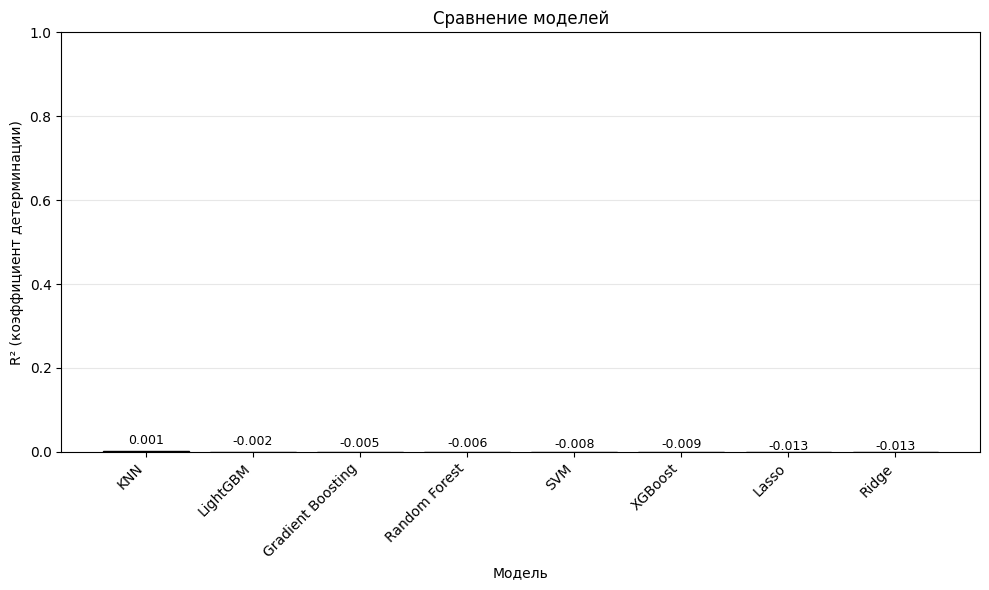

In [82]:
results = pd.DataFrame(results)
results = results.sort_values('R2', ascending=False)
plt.figure(figsize=(10, 6))
bars = plt.bar(results['Model'], results['R2'], color='steelblue', edgecolor='black')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)
plt.xlabel('Модель')
plt.ylabel('R² (коэффициент детерминации)')
plt.title('Сравнение моделей')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [83]:
#проверяем модели только на UMAP признаках
results_umap = []
best_models = {}
print('Модели на UMAP признаках')
for name, config in models.items():
  grid = GridSearchCV(config['model'], config['params'],
        cv=5, scoring='r2', n_jobs=-1, verbose=0)
  grid.fit(X_u_train, y_u_train_log)

  best_model = grid.best_estimator_
  best_models[name] = best_model

  y_pred_log = best_model.predict(X_u_test)
  y_pred = np.expm1(y_pred_log)
  y_true = np.expm1(y_u_test_log)
  r2 = r2_score(y_true, y_pred)
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))

  results_umap.append({'Model': name,
        'Best Params': str(grid.best_params_),
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse,
        'CV R2': grid.best_score_})
  print(f'\n{name}')
  print(f'Лучшие параметры: {grid.best_params_}')
  print(f'R² (исходная шкала): {r2:.4f}')
  print(f'MAE: {mae:.4f}')
  print(f'RMSE: {rmse:.4f}')
  print(f'CV R²: {grid.best_score_:.4f}')

Модели на UMAP признаках

Ridge
Лучшие параметры: {'alpha': 10}
R² (исходная шкала): -0.0143
MAE: 186.7399
RMSE: 1431.4144
CV R²: 0.0915

Lasso
Лучшие параметры: {'alpha': 0.001}
R² (исходная шкала): -0.0142
MAE: 186.7368
RMSE: 1431.3605
CV R²: 0.0914

Random Forest
Лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 3, 'n_estimators': 230}
R² (исходная шкала): -0.0093
MAE: 185.8710
RMSE: 1427.8952
CV R²: 0.1466

Gradient Boosting
Лучшие параметры: {'learning_rate': 0.02, 'max_depth': 3, 'n_estimators': 220, 'subsample': 0.6}
R² (исходная шкала): -0.0093
MAE: 186.5917
RMSE: 1427.9108
CV R²: 0.1027

XGBoost
Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 250}
R² (исходная шкала): -0.0118
MAE: 186.7037
RMSE: 1429.6773
CV R²: 0.1159

LightGBM
Лучшие параметры: {'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 7}
R² (исходная шкала): -0.0083
MAE: 185.9479
RMSE: 1427.1998
CV R²: 0.1590

SVM
Лучшие параметры: {'C': 10, 'epsilon':

все модели показали низкие результаты, поэтому будем рассматривать другие варианты. Проблема заключается в целевой перенной, которая имеет сильный разброс и большое количество выбросов

In [84]:
#запускаем модели менее чувствительные к выбросам
from sklearn.linear_model import HuberRegressor
huber = HuberRegressor(epsilon=1.35, max_iter=1000)
huber.fit(X_a_train_r, y_train_log)
y_pred_log = huber.predict(X_a_test_r)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test_log)
r2_hub = r2_score(y_true, y_pred)
mae_hub = mean_absolute_error(y_true, y_pred)
rmse_hub = np.sqrt(mean_squared_error(y_true, y_pred))
print('Huber')
print(f'Тест R²: {r2_hub:.4f}')
print(f'MAE: {mae_hub:.2f}')
print(f'RMSE: {rmse_hub:.2f}')

Huber
Тест R²: -0.0176
MAE: 188.74
RMSE: 1433.79


In [85]:
#т.к. результат не стал лучше, удаляем выбросы
upper_limit = np.percentile(y_train_log, 95)
mask = y_train_log <= upper_limit

X_train_clean = X_a_train.loc[mask]
y_train_clean_log = y_train_log.loc[mask]

In [86]:
clean_count = len(y_train_clean_log)
clean_count

758

In [87]:
#обучаем модель заново
huber = HuberRegressor(epsilon=1.35, max_iter=1000)
huber.fit(X_train_clean, y_train_clean_log)
y_pred_log = huber.predict(X_a_test_r)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test_log)
r2_hub = r2_score(y_true, y_pred)
mae_hub = mean_absolute_error(y_true, y_pred)
rmse_hub = np.sqrt(mean_squared_error(y_true, y_pred))
print('Huber')
print(f'Тест R²: {r2_hub:.4f}')
print(f'MAE: {mae_hub:.2f}')
print(f'RMSE: {rmse_hub:.2f}')

Huber
Тест R²: -0.0176
MAE: 188.74
RMSE: 1433.79
